# Baseline Comparison Dashboard

Full pipeline (`V_full`) vs. previous goal-to-parameter baseline across BPIC2017, BPIC2012, and Sepsis.
Metrics: Prospect-Theory Score, KPI Directional Hit Rate (DHR), Net Improvement Score (NIS).
Same SIMOD baseline, same KPI sets, seeds 42–51, 1 000 cases per run.

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path(".")

s2   = pd.read_csv(ROOT / "stage2_results" / "stage2_results.csv")
base = pd.read_csv(ROOT / "stage2_results_baseline" / "stage2_results.csv")

s2   = s2[(s2["error"].isna())   | (s2["error"]   == "")].copy()
base = base[(base["error"].isna()) | (base["error"] == "")].copy()

vfull        = s2[s2["variant"] == "V_full"].copy()
vfull["dhr_pct"] = vfull["dhr_mean"] * 100
base["dhr_pct"]  = base["dhr_mean"]  * 100

LOG_ORDER  = ["bpic2017", "bpic2012", "sepsis"]
LOG_LABELS = {"bpic2017": "BPIC 2017", "bpic2012": "BPIC 2012", "sepsis": "Sepsis"}

C_FULL = "#2563eb"   # blue  — full pipeline
C_BASE = "#9ca3af"   # grey  — previous baseline

LEGEND = [
    mpatches.Patch(color=C_FULL, label="Full pipeline (this work)"),
    mpatches.Patch(color=C_BASE, label="Previous baseline"),
]

x     = np.arange(2)   # two bars per subplot
WIDTH = 0.45

def _val(df, log, col):
    return df.loc[df["log"] == log, col].values[0]

def _bar_labels(ax, bars, vals, fmt):
    for bar, v in zip(bars, vals):
        va  = "bottom" if v >= 0 else "top"
        off = abs(ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.015
        off = off if v >= 0 else -off
        ax.text(bar.get_x() + bar.get_width() / 2, v + off,
                fmt.format(v), ha="center", va=va,
                fontsize=9, fontweight="bold")

print("Ready.")

Ready.


## Figure 1 — Prospect-Theory Score

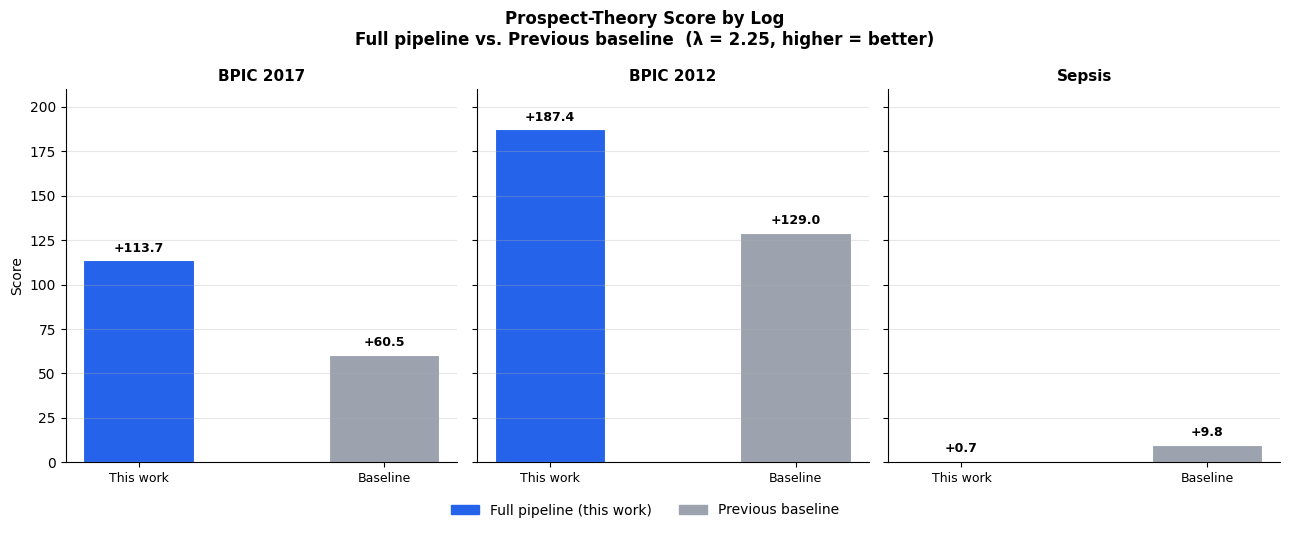

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig.suptitle(
    "Prospect-Theory Score by Log\n"
    "Full pipeline vs. Previous baseline  (λ = 2.25, higher = better)",
    fontsize=12, fontweight="bold",
)

SCORE_YLIM = (0, 210)

for ax, log in zip(axes, LOG_ORDER):
    vf_s = _val(vfull, log, "best_iter_score")
    bl_s = _val(base,  log, "best_iter_score")

    bars = ax.bar(x, [vf_s, bl_s], WIDTH,
                  color=[C_FULL, C_BASE],
                  edgecolor="white", linewidth=0.8)

    ax.set_ylim(*SCORE_YLIM)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(LOG_LABELS[log], fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["This work", "Baseline"], fontsize=9)
    ax.set_ylabel("Score" if ax is axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    _bar_labels(ax, bars, [vf_s, bl_s], "{:+.1f}")

fig.legend(handles=LEGEND, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("figures/comparison_score.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 — KPI Directional Hit Rate (DHR)

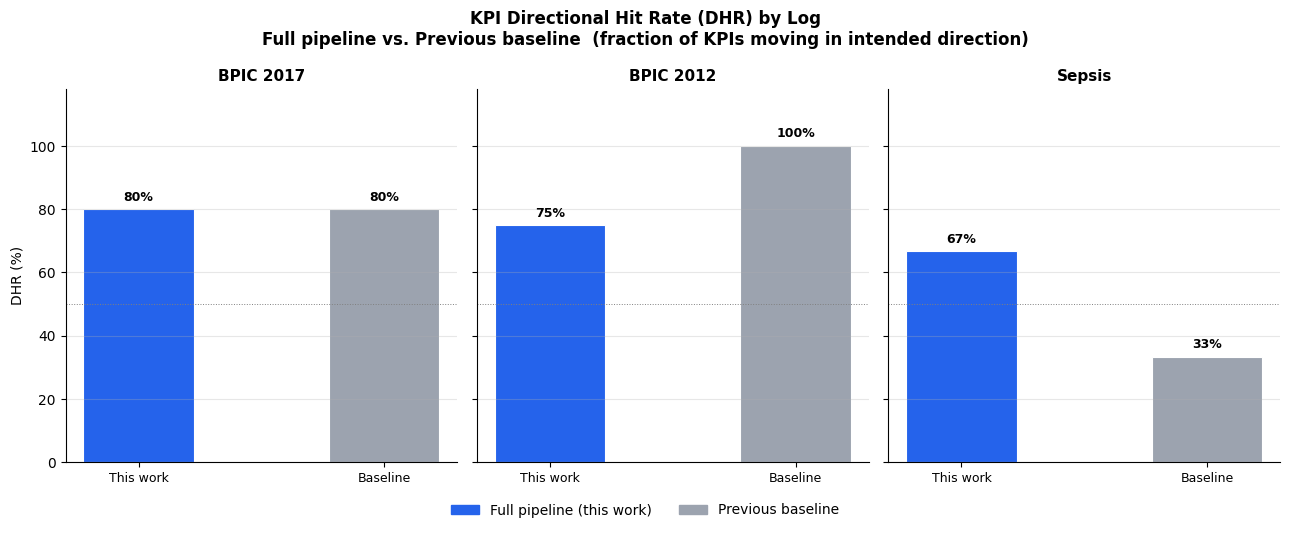

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig.suptitle(
    "KPI Directional Hit Rate (DHR) by Log\n"
    "Full pipeline vs. Previous baseline  (fraction of KPIs moving in intended direction)",
    fontsize=12, fontweight="bold",
)

DHR_YLIM = (0, 118)

for ax, log in zip(axes, LOG_ORDER):
    vf_d = _val(vfull, log, "dhr_pct")
    bl_d = _val(base,  log, "dhr_pct")

    bars = ax.bar(x, [vf_d, bl_d], WIDTH,
                  color=[C_FULL, C_BASE],
                  edgecolor="white", linewidth=0.8)

    ax.set_ylim(*DHR_YLIM)
    ax.axhline(50, color="grey", linewidth=0.7, linestyle=":")
    ax.set_title(LOG_LABELS[log], fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["This work", "Baseline"], fontsize=9)
    ax.set_ylabel("DHR (%)" if ax is axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    _bar_labels(ax, bars, [vf_d, bl_d], "{:.0f}%")

fig.legend(handles=LEGEND, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("figures/comparison_dhr.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 — Net Improvement Score (NIS)

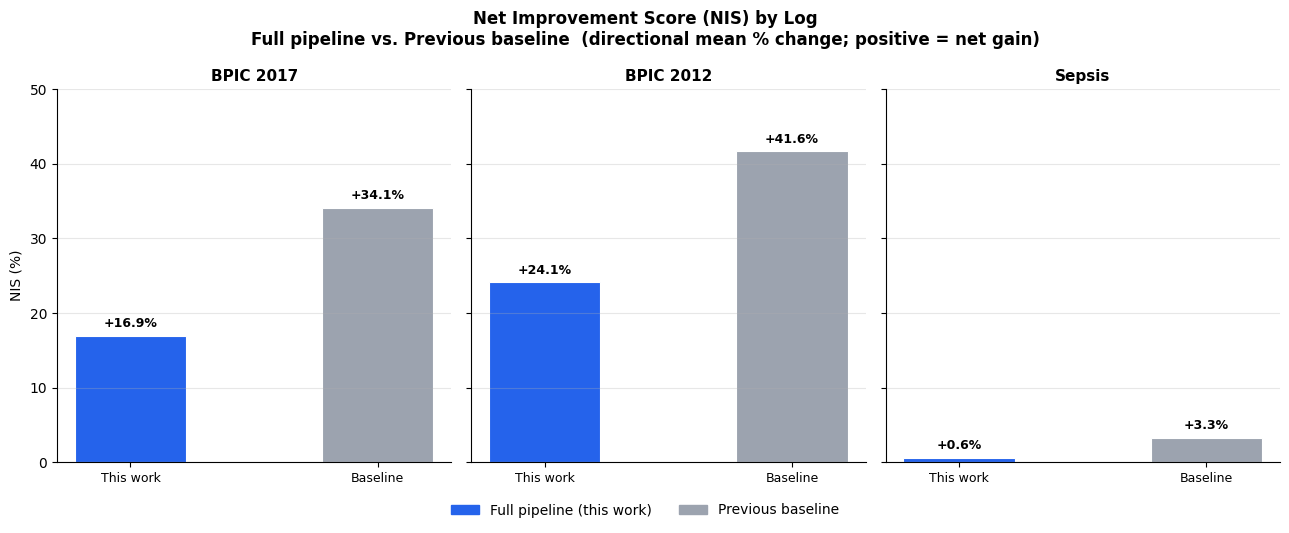

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig.suptitle(
    "Net Improvement Score (NIS) by Log\n"
    "Full pipeline vs. Previous baseline  (directional mean % change; positive = net gain)",
    fontsize=12, fontweight="bold",
)

NIS_YLIM = (0, 50)

for ax, log in zip(axes, LOG_ORDER):
    vf_n = _val(vfull, log, "nis_mean")
    bl_n = _val(base,  log, "nis_mean")

    bars = ax.bar(x, [vf_n, bl_n], WIDTH,
                  color=[C_FULL, C_BASE],
                  edgecolor="white", linewidth=0.8)

    ax.set_ylim(*NIS_YLIM)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(LOG_LABELS[log], fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["This work", "Baseline"], fontsize=9)
    ax.set_ylabel("NIS (%)" if ax is axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    _bar_labels(ax, bars, [vf_n, bl_n], "{:+.1f}%")

fig.legend(handles=LEGEND, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("figures/comparison_nis.png", dpi=150, bbox_inches="tight")
plt.show()